In [ ]:
#Imports principais

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)


import joblib


In [2]:
df = pd.read_csv('base_de_dados_completo_eda.csv')

## Exploração inicial

In [3]:
df.head()

,data_referencia,ra,fase,turma,nome,ano_nasc,idade_22,gênero,ano_ingresso,instituição_de_ensino,...,ing,fase_ideal.1,destaque_ipv_1,inde_2024,pedra_2024,avaliador5,avaliador6,escola,ativo/inativo,ativo/inativo_1
0,2022-01-01,RA-1,7,A,Aluno-1,2003.0,19.0,Menina,2016,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-01,RA-61,5,B,Aluno-61,2007.0,15.0,Menino,2021,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-01,RA-610,1,L,Aluno-610,2013.0,9.0,Menina,2022,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-01,RA-611,1,M,Aluno-611,2010.0,12.0,Menino,2021,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-01,RA-612,1,M,Aluno-612,2012.0,10.0,Menina,2021,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.query('ra == "RA-1000"')

,data_referencia,ra,fase,turma,nome,ano_nasc,idade_22,gênero,ano_ingresso,instituição_de_ensino,...,ing,fase_ideal.1,destaque_ipv_1,inde_2024,pedra_2024,avaliador5,avaliador6,escola,ativo/inativo,ativo/inativo_1
1529,2023-01-01,RA-1000,ALFA,ALFA U - G2/G3,NaN,NaN,NaN,Feminino,2023,Pública,...,NaN,ALFA (1° e 2° ano),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2644,2024-01-01,RA-1000,1N,1N,NaN,NaN,NaN,Feminino,2023,Pública,...,NaN,Fase 1 (3° e 4° ano),NaN,8.364790909100002,Topázio,NaN,NaN,EE Helio Luiz Dobrochinski Prof,Cursando,Cursando


In [5]:
df_pivot = (
    df
    .set_index(["ra", "data_referencia"])
    .unstack("data_referencia")
)

# display(df_pivot.columns)
# achata o MultiIndex das colunas
df_pivot.columns = [f"{col}_{ano}" for col, ano in df_pivot.columns]

df_pivot = df_pivot.reset_index()

df_pivot.head()

,ra,fase_2022-01-01,fase_2023-01-01,fase_2024-01-01,turma_2022-01-01,turma_2023-01-01,turma_2024-01-01,nome_2022-01-01,nome_2023-01-01,nome_2024-01-01,...,avaliador6_2024-01-01,escola_2022-01-01,escola_2023-01-01,escola_2024-01-01,ativo/inativo_2022-01-01,ativo/inativo_2023-01-01,ativo/inativo_2024-01-01,ativo/inativo_1_2022-01-01,ativo/inativo_1_2023-01-01,ativo/inativo_1_2024-01-01
0,RA-1,7,FASE 8,8E,A,8E,8E,Aluno-1,NaN,NaN,...,NaN,NaN,NaN,Universidade Santo Amaro (UNISA),NaN,NaN,Cursando,NaN,NaN,Cursando
1,RA-10,7,NaN,NaN,A,NaN,NaN,Aluno-10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RA-100,4,NaN,NaN,A,NaN,NaN,Aluno-100,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RA-1000,NaN,ALFA,1N,NaN,ALFA U - G2/G3,1N,NaN,NaN,NaN,...,NaN,NaN,NaN,EE Helio Luiz Dobrochinski Prof,NaN,NaN,Cursando,NaN,NaN,Cursando
4,RA-1001,NaN,ALFA,1N,NaN,ALFA U - G2/G3,1N,NaN,NaN,NaN,...,NaN,NaN,NaN,EE Helio Luiz Dobrochinski Prof,NaN,NaN,Cursando,NaN,NaN,Cursando


In [6]:
df_pivot[df_pivot.columns[df_pivot.columns.str.contains('fase')]]

,fase_2022-01-01,fase_2023-01-01,fase_2024-01-01,fase_ideal_2022-01-01,fase_ideal_2023-01-01,fase_ideal_2024-01-01,fase_ideal.1_2022-01-01,fase_ideal.1_2023-01-01,fase_ideal.1_2024-01-01
0,7,FASE 8,8E,Fase 8 (Universitários),NaN,NaN,NaN,Fase 8 (Universitários),Fase 8 (Universitários)
1,7,NaN,NaN,Fase 8 (Universitários),NaN,NaN,NaN,NaN,NaN
2,4,NaN,NaN,Fase 3 (7º e 8º ano),NaN,NaN,NaN,NaN,NaN
3,NaN,ALFA,1N,NaN,NaN,NaN,NaN,ALFA (1° e 2° ano),Fase 1 (3° e 4° ano)
4,NaN,ALFA,1N,NaN,NaN,NaN,NaN,Fase 1 (3° e 4° ano),Fase 2 (5° e 6° ano)
...,...,...,...,...,...,...,...,...,...
1656,NaN,ALFA,1E,NaN,NaN,NaN,NaN,Fase 2 (5° e 6° ano),Fase 3 (7° e 8° ano)
1657,NaN,ALFA,NaN,NaN,NaN,NaN,NaN,Fase 1 (3° e 4° ano),NaN
1658,NaN,ALFA,NaN,NaN,NaN,NaN,NaN,ALFA (1° e 2° ano),NaN
1659,NaN,ALFA,NaN,NaN,NaN,NaN,NaN,Fase 2 (5° e 6° ano),NaN


In [7]:
df_pivot[df_pivot['fase_2024-01-01'].isna()].head()
# Alunos com fase_2024-01-01 vazia não aparecem na base de 2024

,ra,fase_2022-01-01,fase_2023-01-01,fase_2024-01-01,turma_2022-01-01,turma_2023-01-01,turma_2024-01-01,nome_2022-01-01,nome_2023-01-01,nome_2024-01-01,...,avaliador6_2024-01-01,escola_2022-01-01,escola_2023-01-01,escola_2024-01-01,ativo/inativo_2022-01-01,ativo/inativo_2023-01-01,ativo/inativo_2024-01-01,ativo/inativo_1_2022-01-01,ativo/inativo_1_2023-01-01,ativo/inativo_1_2024-01-01
1,RA-10,7,NaN,NaN,A,NaN,NaN,Aluno-10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RA-100,4,NaN,NaN,A,NaN,NaN,Aluno-100,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,RA-1005,NaN,ALFA,NaN,NaN,ALFA V - G0/G1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,RA-1007,NaN,ALFA,NaN,NaN,ALFA V - G0/G1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,RA-101,4,NaN,NaN,A,NaN,NaN,Aluno-101,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df_pivot["fase_2024-01-01"].unique()

array(['8E', nan, '1N', 'ALFA', '2B', '2C', '1A', '1B', '1C', '5A', '2D',
       '2H', '2I', '1H', '2G', '2A', '1J', '1L', '1K', '2M', '6A', '2N',
       '2L', '2R', '2K', '5D', '1P', '3B', '3A', '3D', '4C', '3C', '3G',
       '3H', '3F', '5B', '3I', '3M', '3K', '3N', '5G', '3U', '3R', '3P',
       '2P', '3L', '4A', '4F', '4M', '4N', '4R', '5C', '5F', '7E', '4L',
       '5N', '6L', '5M', '7A', '8F', '9', '8A', '8B', '8D', '1D', '1E',
       '1G', '1M', '1R', '2U', '5L', '4B', '4H'], dtype=object)

### Normalização fase (apenas 2024)

In [9]:
def normaliza_fase(fase):
    if pd.isna(fase):
        return fase

    if fase.lower() == 'alfa':
        return 0

    return fase[0]

In [10]:
df_pivot['fase_2024'] = df_pivot["fase_2024-01-01"].apply(normaliza_fase)
# valore NaN nessa coluna significam que o aluno não estava na base de 2024

### Removendo sufixo mes-dia das colunas pivotadas

In [11]:
df_pivot.columns = df_pivot.columns.map(lambda col: col.replace('-01-01', ''))

In [12]:
df_pivot.head()

,ra,fase_2022,fase_2023,fase_2024,turma_2022,turma_2023,turma_2024,nome_2022,nome_2023,nome_2024,...,escola_2022,escola_2023,escola_2024,ativo/inativo_2022,ativo/inativo_2023,ativo/inativo_2024,ativo/inativo_1_2022,ativo/inativo_1_2023,ativo/inativo_1_2024,fase_2024
0,RA-1,7,FASE 8,8E,A,8E,8E,Aluno-1,NaN,NaN,...,NaN,NaN,Universidade Santo Amaro (UNISA),NaN,NaN,Cursando,NaN,NaN,Cursando,8
1,RA-10,7,NaN,NaN,A,NaN,NaN,Aluno-10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RA-100,4,NaN,NaN,A,NaN,NaN,Aluno-100,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RA-1000,NaN,ALFA,1N,NaN,ALFA U - G2/G3,1N,NaN,NaN,NaN,...,NaN,NaN,EE Helio Luiz Dobrochinski Prof,NaN,NaN,Cursando,NaN,NaN,Cursando,1
4,RA-1001,NaN,ALFA,1N,NaN,ALFA U - G2/G3,1N,NaN,NaN,NaN,...,NaN,NaN,EE Helio Luiz Dobrochinski Prof,NaN,NaN,Cursando,NaN,NaN,Cursando,1


## Perguntas a serem respondidas Tech 5

### 1. Adequação do nível (IAN): Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?

In [13]:
df_pivot.columns[df_pivot.columns.str.contains('ian')]

Index(['ian_2022', 'ian_2023', 'ian_2024'], dtype='object')

In [14]:
df_pivot.loc[:, df_pivot.columns.str.contains('ian')].head()

,ian_2022,ian_2023,ian_2024
0,5.0,10.0,10.0
1,5.0,NaN,NaN
2,10.0,NaN,NaN
3,NaN,10.0,10.0
4,NaN,5.0,5.0


In [15]:
df_pivot.loc[:, df_pivot.columns.str.contains('ian')].fillna(False).all(axis=1)

0        True
1       False
2       False
3       False
4       False
        ...  
1656    False
1657    False
1658    False
1659    False
1660    False
Length: 1661, dtype: bool

#### Avaliando apenas alunos presentes em todos os anos

In [16]:
df_todos_os_anos_ian = df_pivot[df_pivot.loc[:, df_pivot.columns.str.contains('ian')].fillna(False).all(axis=1)]

In [17]:
df_todos_os_anos_ian.head()

,ra,fase_2022,fase_2023,fase_2024,turma_2022,turma_2023,turma_2024,nome_2022,nome_2023,nome_2024,...,escola_2022,escola_2023,escola_2024,ativo/inativo_2022,ativo/inativo_2023,ativo/inativo_2024,ativo/inativo_1_2022,ativo/inativo_1_2023,ativo/inativo_1_2024,fase_2024
0,RA-1,7,FASE 8,8E,A,8E,8E,Aluno-1,NaN,NaN,...,NaN,NaN,Universidade Santo Amaro (UNISA),NaN,NaN,Cursando,NaN,NaN,Cursando,8
35,RA-103,4,FASE 5,5A,A,5A,5A,Aluno-103,NaN,NaN,...,NaN,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,5
68,RA-106,4,FASE 5,6A,A,5A,6A,Aluno-106,NaN,NaN,...,NaN,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,6
79,RA-107,4,FASE 5,5D,A,5C,5D,Aluno-107,NaN,NaN,...,NaN,NaN,EE Mario Francisco de Amorim,NaN,NaN,Cursando,NaN,NaN,Cursando,5
113,RA-110,4,FASE 5,5A,A,5A,5A,Aluno-110,NaN,NaN,...,NaN,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,5


In [18]:
df_todos_os_anos_ian.loc[:, df_todos_os_anos_ian.columns.str.contains('ian')]

,ian_2022,ian_2023,ian_2024
0,5.0,10.0,10.0
35,10.0,10.0,10.0
68,5.0,10.0,10.0
79,5.0,10.0,5.0
113,10.0,10.0,10.0
...,...,...,...
1573,5.0,5.0,10.0
1584,10.0,10.0,10.0
1595,10.0,5.0,10.0
1617,5.0,5.0,10.0


In [19]:
df_todos_os_anos_ian.loc[:, df_todos_os_anos_ian.columns.str.contains('ian')]

df_todos_os_anos_ian['delta_ian'] = np.where(
    df_todos_os_anos_ian['ian_2024'] - df_todos_os_anos_ian['ian_2022'] > 0, 'positivo',
    np.where(df_todos_os_anos_ian['ian_2024'] - df_todos_os_anos_ian['ian_2022'] < 0, 'negativo', 'estavel')
)

C:\Users\luish\AppData\Local\Temp\ipykernel_3772\1050806954.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_todos_os_anos_ian['delta_ian'] = np.where(


In [20]:
df_todos_os_anos_ian.head()

,ra,fase_2022,fase_2023,fase_2024,turma_2022,turma_2023,turma_2024,nome_2022,nome_2023,nome_2024,...,escola_2023,escola_2024,ativo/inativo_2022,ativo/inativo_2023,ativo/inativo_2024,ativo/inativo_1_2022,ativo/inativo_1_2023,ativo/inativo_1_2024,fase_2024,delta_ian
0,RA-1,7,FASE 8,8E,A,8E,8E,Aluno-1,NaN,NaN,...,NaN,Universidade Santo Amaro (UNISA),NaN,NaN,Cursando,NaN,NaN,Cursando,8,positivo
35,RA-103,4,FASE 5,5A,A,5A,5A,Aluno-103,NaN,NaN,...,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,5,estavel
68,RA-106,4,FASE 5,6A,A,5A,6A,Aluno-106,NaN,NaN,...,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,6,positivo
79,RA-107,4,FASE 5,5D,A,5C,5D,Aluno-107,NaN,NaN,...,NaN,EE Mario Francisco de Amorim,NaN,NaN,Cursando,NaN,NaN,Cursando,5,estavel
113,RA-110,4,FASE 5,5A,A,5A,5A,Aluno-110,NaN,NaN,...,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,5,estavel


*Analisando os dados dos alunos presentes nos três anos disponíveis podemos ver que um percentual baixo apresentou piora na defasagem, apenas 6,4%*

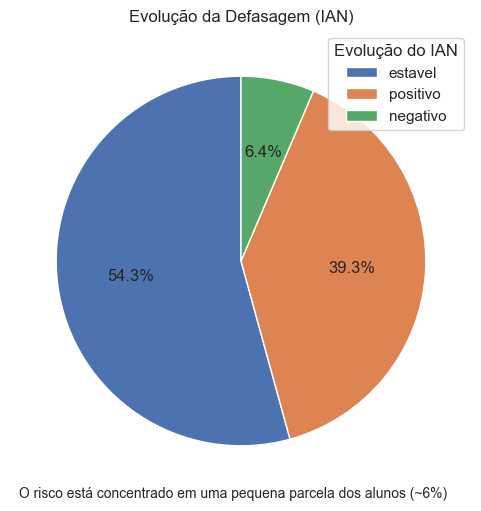

In [85]:
plt.figure(figsize=(6,6))

df_todos_os_anos_ian['delta_ian'].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    labels=None  # remove labels do gráfico (fica mais limpo)
)

# legenda bonita
plt.legend(
    df_todos_os_anos_ian['delta_ian'].value_counts().index,
    title="Evolução do IAN",
    loc="upper right"
)

plt.title("Evolução da Defasagem (IAN)")

# insight como legenda inferior
plt.figtext(
    0.5, 0.1,
    "O risco está concentrado em uma pequena parcela dos alunos (~6%)",
    ha="center",
    fontsize=10
)

plt.ylabel("")  # remove eixo
plt.show()

In [22]:
print(df_todos_os_anos_ian.columns.tolist())

['ra', 'fase_2022', 'fase_2023', 'fase_2024', 'turma_2022', 'turma_2023', 'turma_2024', 'nome_2022', 'nome_2023', 'nome_2024', 'ano_nasc_2022', 'ano_nasc_2023', 'ano_nasc_2024', 'idade_22_2022', 'idade_22_2023', 'idade_22_2024', 'gênero_2022', 'gênero_2023', 'gênero_2024', 'ano_ingresso_2022', 'ano_ingresso_2023', 'ano_ingresso_2024', 'instituição_de_ensino_2022', 'instituição_de_ensino_2023', 'instituição_de_ensino_2024', 'pedra_20_2022', 'pedra_20_2023', 'pedra_20_2024', 'pedra_21_2022', 'pedra_21_2023', 'pedra_21_2024', 'pedra_22_2022', 'pedra_22_2023', 'pedra_22_2024', 'inde_22_2022', 'inde_22_2023', 'inde_22_2024', 'cg_2022', 'cg_2023', 'cg_2024', 'cf_2022', 'cf_2023', 'cf_2024', 'ct_2022', 'ct_2023', 'ct_2024', 'nº_av_2022', 'nº_av_2023', 'nº_av_2024', 'avaliador1_2022', 'avaliador1_2023', 'avaliador1_2024', 'rec_av1_2022', 'rec_av1_2023', 'rec_av1_2024', 'avaliador2_2022', 'avaliador2_2023', 'avaliador2_2024', 'rec_av2_2022', 'rec_av2_2023', 'rec_av2_2024', 'avaliador3_2022', 'a

In [23]:
df_todos_os_anos_ian.columns = (
    df_todos_os_anos_ian.columns
    .str.strip()
    .str.replace("\n", "", regex=True)
)

In [24]:
print(df_todos_os_anos_ian["delta_ian"].dtype)


object


In [25]:
df_todos_os_anos_ian_estavel = df_todos_os_anos_ian[
    df_todos_os_anos_ian["delta_ian"] == "estavel"
]


*Os alunos que mantiveram o IAN estável nos três anos não pertencem a faixa mais negativa do indicador, com 2 anos ou mais de defasagem*

In [26]:
df_todos_os_anos_ian_estavel['ian_2024'].value_counts()

ian_2024
5.0     129
10.0    125
Name: count, dtype: int64

### 2. Desempenho acadêmico (IDA): O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

In [27]:
df_todos_os_anos_ida = df_pivot[df_pivot.loc[:, ["ida_2022", "ida_2023", "ida_2024"]].fillna(False).all(axis=1)]

In [28]:
df_todos_os_anos_ida.shape

(429, 188)

In [29]:
df_todos_os_anos_ida['delta_ida'] = np.where(
    df_todos_os_anos_ida['ida_2024'] - df_todos_os_anos_ida['ida_2022'] > 0, 'positivo',
    np.where(df_todos_os_anos_ida['ida_2024'] - df_todos_os_anos_ida['ida_2022'] < 0, 'negativo', 'estavel')
)

C:\Users\luish\AppData\Local\Temp\ipykernel_3772\2456152967.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_todos_os_anos_ida['delta_ida'] = np.where(


In [30]:
df_todos_os_anos_ida.loc[:, ["ida_2022", "ida_2023", "ida_2024", "delta_ida"]].head()

,ida_2022,ida_2023,ida_2024,delta_ida
35,7.3,7.1,9.166667,positivo
68,7.4,7.3,5.666667,negativo
79,4.6,7.0,4.666667,positivo
113,6.7,7.5,8.500000,positivo
124,8.0,6.0,8.333333,positivo


<Axes: ylabel='count'>

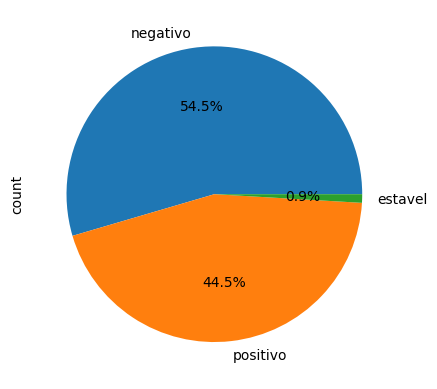

In [31]:
df_todos_os_anos_ida['delta_ida'].value_counts().plot.pie(autopct="%1.1f%%")

In [32]:
df_todos_os_anos_ida[["ida_2022", "ida_2023", "ida_2024"]].mean()

ida_2022    6.680653
ida_2023    6.785781
ida_2024    6.294172
dtype: float64

### 3. Engajamento nas atividades (IEG): O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

In [33]:
df_todos_os_anos_ieg = df_pivot[df_pivot.loc[:, ["ieg_2022", "ieg_2023", "ieg_2024"]].fillna(False).all(axis=1)]

In [34]:
df_todos_os_anos_ieg.shape

(432, 188)

In [35]:

colunas_analise_ieg = [
    "ieg_2022",
    "ieg_2023",
    "ieg_2024",
    "ida_2022",
    "ida_2023",
    "ida_2024",
    "ipv_2022",
    "ipv_2023",
    "ipv_2024"
]

In [36]:
df_todos_os_anos_ieg[colunas_analise_ieg].head()

,ieg_2022,ieg_2023,ieg_2024,ida_2022,ida_2023,ida_2024,ipv_2022,ipv_2023,ipv_2024
35,8.7,9.2,9.603175,7.3,7.1,9.166667,7.708,8.0900,8.872
68,8.0,9.1,8.761905,7.4,7.3,5.666667,8.375,7.5075,7.872
79,6.4,8.5,7.994987,4.6,7.0,4.666667,6.500,7.5875,6.964
113,9.7,8.6,9.696970,6.7,7.5,8.500000,8.000,8.2975,8.504
124,9.4,8.7,9.488636,8.0,6.0,8.333333,8.667,8.0875,8.740


In [37]:
df_ieg_2024 = df_todos_os_anos_ieg[filter(lambda col: "2024" in col, colunas_analise_ieg)]

In [38]:
df_ieg_2024.corr()

,ieg_2024,ida_2024,ipv_2024
ieg_2024,1.000000,0.565379,0.649079
ida_2024,0.565379,1.000000,0.638937
ipv_2024,0.649079,0.638937,1.000000


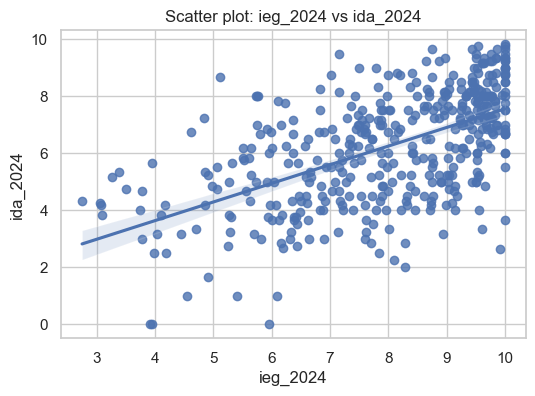

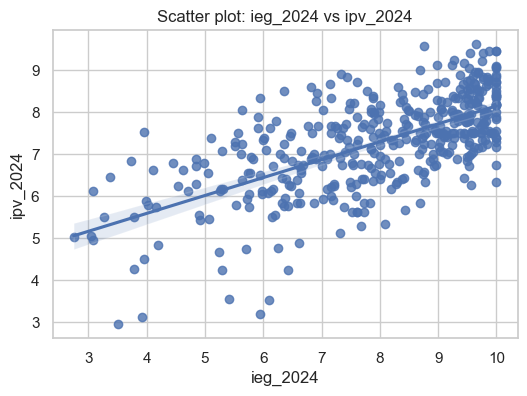

In [39]:
# estilo opcional
sns.set(style="whitegrid")

# Scatter: ieg_2024 x ida_2024
plt.figure(figsize=(6, 4))
sns.regplot(data=df_ieg_2024, x="ieg_2024", y="ida_2024")
plt.title("Scatter plot: ieg_2024 vs ida_2024")
plt.show()

# Scatter: ieg_2024 x ipv_2024
plt.figure(figsize=(6, 4))
sns.regplot(data=df_ieg_2024, x="ieg_2024", y="ipv_2024")
plt.title("Scatter plot: ieg_2024 vs ipv_2024")
plt.show()

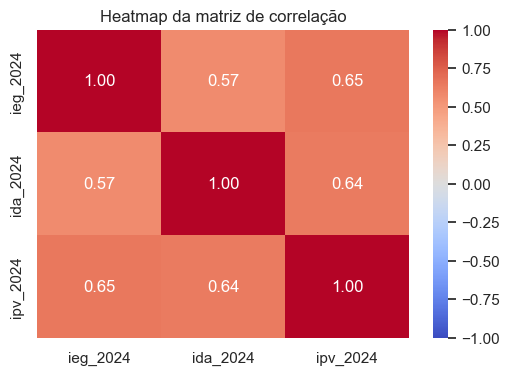

In [40]:
# matriz de correlação
corr = df_ieg_2024[["ieg_2024", "ida_2024", "ipv_2024"]].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr,
    annot=True,        # mostra os valores
    fmt=".2f",         # casas decimais
    cmap="coolwarm",   # esquema de cores
    vmin=-1,
    vmax=1
)

plt.title("Heatmap da matriz de correlação")
plt.show()

*IDA e IPV possuem correlação moderada com o IEG (0,56 e 0,64 respectivamente)*

- IDA = Indicador de desempenho acadêmico: Notas de provas e média geral universitária
- IPV = Indicador do ponto de virada: Questionário individual de avaliação dos pedagogos e professores (Avaliação psicopedagógica, subjetivo?)
- **IEG** = Indicador de engajamento: Registro de entrega de lição de cada e voluntariado

### 4. Autoavaliação (IAA): As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

- **IAA**: Indicador de autoavaliação
- IDA: Indicador de desenvolvimento acadêmico - (Nota Matemática + Nota Português + Nota Inglês) / 3
- IEG: Indicador de engajamento - Soma das pontuações das tarefas realizadas e registradas / Número de tarefas

In [41]:
df_iaa_todos_anos = df_pivot[df_pivot.loc[:,df_pivot.columns.str.contains("iaa")].fillna(False).all(axis=1)]

In [42]:
df_iaa_todos_anos.shape

(338, 188)

In [43]:
df_iaa_todos_anos.head()

,ra,fase_2022,fase_2023,fase_2024,turma_2022,turma_2023,turma_2024,nome_2022,nome_2023,nome_2024,...,escola_2022,escola_2023,escola_2024,ativo/inativo_2022,ativo/inativo_2023,ativo/inativo_2024,ativo/inativo_1_2022,ativo/inativo_1_2023,ativo/inativo_1_2024,fase_2024
35,RA-103,4,FASE 5,5A,A,5A,5A,Aluno-103,NaN,NaN,...,NaN,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,5
68,RA-106,4,FASE 5,6A,A,5A,6A,Aluno-106,NaN,NaN,...,NaN,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,6
113,RA-110,4,FASE 5,5A,A,5A,5A,Aluno-110,NaN,NaN,...,NaN,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,5
124,RA-111,4,FASE 5,5B,A,5A,5B,Aluno-111,NaN,NaN,...,NaN,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,5
135,RA-112,4,FASE 5,6A,A,5A,6A,Aluno-112,NaN,NaN,...,NaN,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,6


In [44]:
df_iaa_todos_anos_cols_indicadores = df_iaa_todos_anos.loc[:,df_iaa_todos_anos.columns.str.contains(r"^iaa_|^ida_|^ieg_", regex=True)]

In [45]:
df_iaa_todos_anos_cols_indicadores.describe()

,iaa_2022,iaa_2023,iaa_2024,ieg_2022,ieg_2023,ieg_2024,ida_2022,ida_2023,ida_2024
count,338.000000,338.000000,338.000000,338.000000,333.000000,338.000000,338.000000,333.000000,338.000000
mean,8.788462,8.571302,8.680322,8.655030,8.823423,8.116524,6.826923,6.811712,6.380671
std,0.907184,1.193816,0.925169,1.138895,1.022661,1.835898,1.778244,1.421314,2.060098
min,5.200000,1.700000,4.584000,3.500000,4.100000,0.000000,1.300000,2.200000,0.000000
25%,8.300000,7.900000,8.002000,8.200000,8.300000,7.299901,5.700000,6.000000,5.000000
50%,9.000000,8.800000,8.751000,8.900000,9.100000,8.696197,7.100000,6.900000,6.750000
75%,9.500000,9.500000,9.418500,9.400000,9.600000,9.543571,8.100000,7.900000,8.000000
max,10.000000,10.000000,10.002000,10.000000,10.000000,10.000000,9.900000,9.700000,9.833333


In [46]:
df_iaa_todos_anos_cols_indicadores.loc[:, df_iaa_todos_anos_cols_indicadores.columns.str.contains('2022')].corr()

,iaa_2022,ieg_2022,ida_2022
iaa_2022,1.000000,0.050360,0.117641
ieg_2022,0.050360,1.000000,0.409565
ida_2022,0.117641,0.409565,1.000000


In [47]:
'''
delta < 0 -> subestima
delta > 0 -> superestima
'''

df_iaa_todos_anos_cols_indicadores['delta_iaa_ieg_2022'] = df_iaa_todos_anos_cols_indicadores['iaa_2022'] - df_iaa_todos_anos_cols_indicadores['ieg_2022']
df_iaa_todos_anos_cols_indicadores['delta_iaa_ida_2022'] = df_iaa_todos_anos_cols_indicadores['iaa_2022'] - df_iaa_todos_anos_cols_indicadores['ida_2022']

df_iaa_todos_anos_cols_indicadores['delta_iaa_ieg_2023'] = df_iaa_todos_anos_cols_indicadores['iaa_2023'] - df_iaa_todos_anos_cols_indicadores['ieg_2023']
df_iaa_todos_anos_cols_indicadores['delta_iaa_ida_2023'] = df_iaa_todos_anos_cols_indicadores['iaa_2023'] - df_iaa_todos_anos_cols_indicadores['ida_2023']

df_iaa_todos_anos_cols_indicadores['delta_iaa_ieg_2024'] = df_iaa_todos_anos_cols_indicadores['iaa_2024'] - df_iaa_todos_anos_cols_indicadores['ieg_2024']
df_iaa_todos_anos_cols_indicadores['delta_iaa_ida_2024'] = df_iaa_todos_anos_cols_indicadores['iaa_2024'] - df_iaa_todos_anos_cols_indicadores['ida_2024']

C:\Users\luish\AppData\Local\Temp\ipykernel_3772\276310651.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_iaa_todos_anos_cols_indicadores['delta_iaa_ieg_2022'] = df_iaa_todos_anos_cols_indicadores['iaa_2022'] - df_iaa_todos_anos_cols_indicadores['ieg_2022']
C:\Users\luish\AppData\Local\Temp\ipykernel_3772\276310651.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_iaa_todos_anos_cols_indicadores['delta_iaa_ida_2022'] = df_iaa_todos_anos_cols_indicadores['iaa_2022'] - df_iaa_todos_anos_cols_indi

In [48]:
display(df_iaa_todos_anos_cols_indicadores.query("iaa_2022 > 0 and ieg_2022 > 0")['delta_iaa_ieg_2022'].describe())
display(df_iaa_todos_anos_cols_indicadores.query("iaa_2022 > 0 and ida_2022 > 0")['delta_iaa_ida_2022'].describe())

count    338.000000
mean       0.133432
std        1.419859
min       -4.000000
25%       -0.800000
50%        0.100000
75%        0.900000
max        6.000000
Name: delta_iaa_ieg_2022, dtype: float64

count    338.000000
mean       1.961538
std        1.898836
min       -2.700000
25%        0.500000
50%        1.800000
75%        3.000000
max        7.700000
Name: delta_iaa_ida_2022, dtype: float64

In [49]:
display(df_iaa_todos_anos_cols_indicadores['delta_iaa_ieg_2023'].describe())
display(df_iaa_todos_anos_cols_indicadores['delta_iaa_ida_2023'].describe())

display(df_iaa_todos_anos_cols_indicadores.query("iaa_2023 > 0 and ieg_2023 > 0")['delta_iaa_ieg_2023'].describe())
display(df_iaa_todos_anos_cols_indicadores.query("iaa_2023 > 0 and ida_2023 > 0")['delta_iaa_ida_2023'].describe())

count    333.000000
mean      -0.245946
std        1.528078
min       -6.400000
25%       -1.200000
50%       -0.200000
75%        0.500000
max        5.900000
Name: delta_iaa_ieg_2023, dtype: float64

count    333.000000
mean       1.765766
std        1.782740
min       -5.500000
25%        0.600000
50%        1.700000
75%        2.800000
max        6.900000
Name: delta_iaa_ida_2023, dtype: float64

count    333.000000
mean      -0.245946
std        1.528078
min       -6.400000
25%       -1.200000
50%       -0.200000
75%        0.500000
max        5.900000
Name: delta_iaa_ieg_2023, dtype: float64

count    333.000000
mean       1.765766
std        1.782740
min       -5.500000
25%        0.600000
50%        1.700000
75%        2.800000
max        6.900000
Name: delta_iaa_ida_2023, dtype: float64

In [50]:
display(df_iaa_todos_anos_cols_indicadores['delta_iaa_ieg_2024'].describe())
display(df_iaa_todos_anos_cols_indicadores['delta_iaa_ida_2024'].describe())

display(df_iaa_todos_anos_cols_indicadores.query("iaa_2024 > 0 and ieg_2024 > 0")['delta_iaa_ieg_2024'].describe())
display(df_iaa_todos_anos_cols_indicadores.query("iaa_2024 > 0 and ida_2024 > 0")['delta_iaa_ida_2024'].describe())

count    338.000000
mean       0.563798
std        1.871341
min       -3.037333
25%       -0.748000
50%        0.140947
75%        1.499799
max        9.168000
Name: delta_iaa_ieg_2024, dtype: float64

count    338.000000
mean       2.299652
std        2.140222
min       -2.248000
25%        0.752000
50%        2.002000
75%        3.563500
max        9.168000
Name: delta_iaa_ida_2024, dtype: float64

count    335.000000
mean       0.490480
std        1.710225
min       -3.037333
25%       -0.753952
50%        0.130364
75%        1.444443
max        7.251482
Name: delta_iaa_ieg_2024, dtype: float64

count    333.000000
mean       2.206539
std        2.014683
min       -2.248000
25%        0.752000
50%        2.002000
75%        3.502000
max        8.585000
Name: delta_iaa_ida_2024, dtype: float64

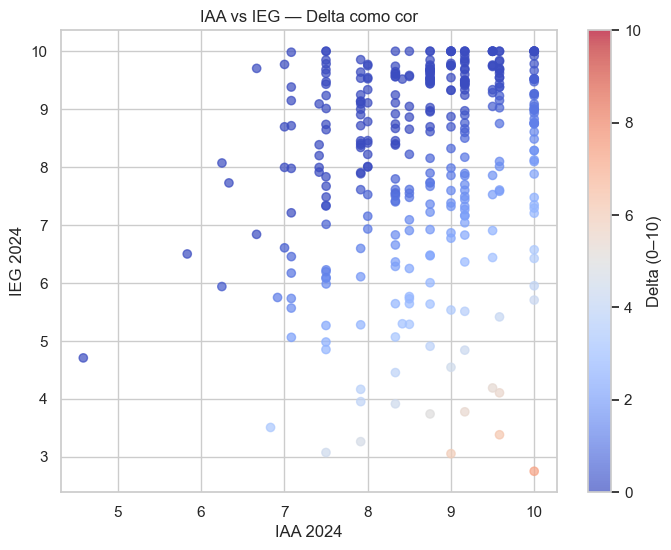

In [51]:
df_plot = df_iaa_todos_anos_cols_indicadores.query("iaa_2024 > 0 and ieg_2024 > 0")[['iaa_2024', 'ieg_2024', 'delta_iaa_ieg_2024']]

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df_plot['iaa_2024'],
    df_plot['ieg_2024'],
    c=df_plot['delta_iaa_ieg_2024'],
    cmap='coolwarm',   # azul → vermelho
    vmin=0,            # azul fixo
    vmax=10,           # vermelho fixo
    alpha=0.7
)

plt.colorbar(scatter, label='Delta (0–10)')
plt.xlabel('IAA 2024')
plt.ylabel('IEG 2024')
plt.title('IAA vs IEG — Delta como cor')

plt.show()

Text(0.5, 1.0, 'IAA vs IDA — Delta como cor')

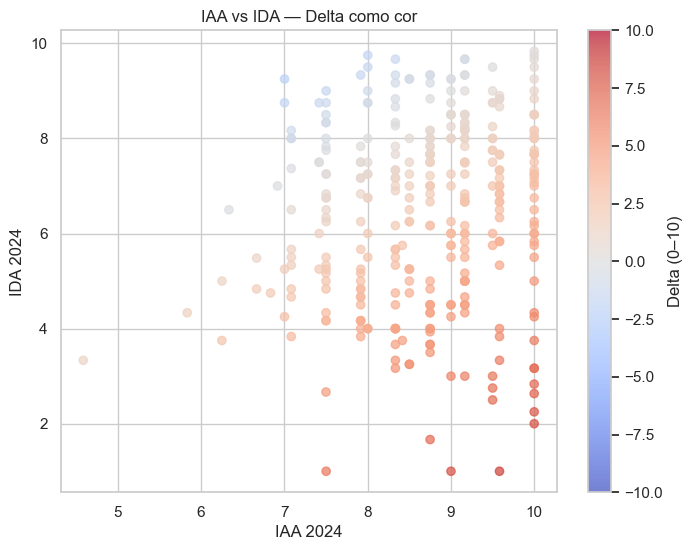

In [52]:
df_plot = df_iaa_todos_anos_cols_indicadores.query("iaa_2024 > 0 and ida_2024 > 0")[['iaa_2024', 'ida_2024', 'delta_iaa_ida_2024']]
                                                                                    

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df_plot['iaa_2024'],
    df_plot['ida_2024'],
    c=df_plot['delta_iaa_ida_2024'],
    cmap='coolwarm',   # azul → vermelho
    vmin=-10,            # azul fixo
    vmax=10,           # vermelho fixo
    alpha=0.7
)

plt.colorbar(scatter, label='Delta (0–10)')
plt.xlabel('IAA 2024')
plt.ylabel('IDA 2024')
plt.title('IAA vs IDA — Delta como cor')

In [53]:
df_iaa_todos_anos_cols_indicadores.sort_values(by='delta_iaa_ieg_2024', ascending=False).query("iaa_2024 > 0 and ieg_2024 > 0").head()

,iaa_2022,iaa_2023,iaa_2024,ieg_2022,ieg_2023,ieg_2024,ida_2022,ida_2023,ida_2024,delta_iaa_ieg_2022,delta_iaa_ida_2022,delta_iaa_ieg_2023,delta_iaa_ida_2023,delta_iaa_ieg_2024,delta_iaa_ida_2024
1168,9.5,7.4,10.002,8.1,8.1,2.750518,4.4,3.9,4.333333,1.4,5.1,-0.7,3.5,7.251482,5.668667
1247,7.4,9.0,9.585,7.6,9.2,3.380451,1.3,6.5,5.333333,-0.2,6.1,-0.2,2.5,6.204549,4.251667
1227,7.8,10.0,9.002,9.6,7.5,3.054348,6.3,6.2,4.250000,-1.8,1.5,2.5,3.8,5.947652,4.752000
545,9.2,8.8,9.585,6.5,4.2,4.104379,5.0,4.7,3.833333,2.7,4.2,4.6,4.1,5.480621,5.751667
1171,9.0,7.8,9.168,8.5,9.4,3.776398,4.3,6.0,3.000000,0.5,4.7,-1.6,1.8,5.391602,6.168000


### 5. Aspectos psicossociais (IPS): Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

Resposta: **Embora não haja uma correlação direta imediata, observou-se que uma queda significativa no bem-estar psicossocial (IPS) em um ano (ex: 2023) precede uma queda no desempenho acadêmico (IDA) e no engajamento (IEG) no ano seguinte (2024).
Sinal de Alerta: A queda de 1,78 pontos no IPS médio entre 2022 e 2023 serviu como um 'aviso', antes mesmo das notas ou da participação caírem**

In [54]:
media_ips = df.groupby(['ips']).agg(
    desempenho_academico=('ida', 'mean'),
    engajamento=('ieg', 'mean'),
).reset_index().round(2).sort_values(by='ips', ascending=False)

media_ips

,ips,desempenho_academico,engajamento
56,10.00,5.80,8.60
55,9.40,7.51,9.14
53,9.38,8.46,9.03
54,9.38,6.26,8.01
52,8.80,7.19,8.15
50,8.76,5.77,7.56
51,8.76,5.82,8.48
49,8.75,4.17,8.50
47,8.14,6.30,8.31
48,8.14,7.13,8.70


In [55]:
temporal_ips = df.groupby(['data_referencia']).agg(
    psicossociais=('ips', 'mean'),
    desempenho_academico=('ida', 'mean'),
    engajamento=('ieg', 'mean'),
).reset_index().round(2).sort_values(by='data_referencia', ascending=True)

temporal_ips

,data_referencia,psicossociais,desempenho_academico,engajamento
0,2022-01-01,6.90,6.09,7.89
1,2023-01-01,5.12,6.66,8.70
2,2024-01-01,6.83,6.35,7.37


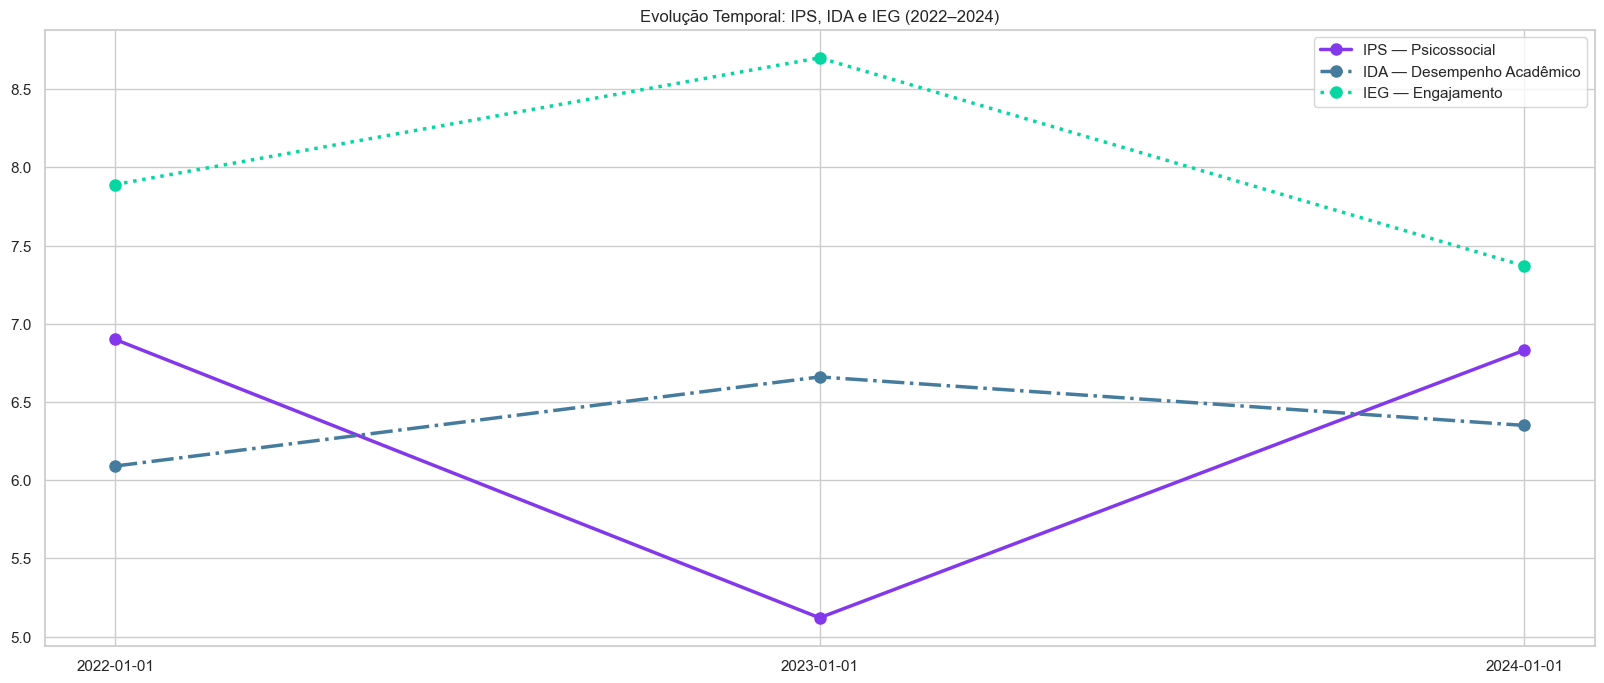

In [56]:
dados_usaveis = temporal_ips.set_index("data_referencia")

fig, ax = plt.subplots(figsize=(20, 8))

cores = {'psicossociais': '#8338EC', 'desempenho_academico': '#457B9D', 'engajamento': '#06D6A0'}
estilos = {'psicossociais': '-', 'desempenho_academico': '-.', 'engajamento': ':'}
labels = {'psicossociais': 'IPS — Psicossocial', 'desempenho_academico': 'IDA — Desempenho Acadêmico', 'engajamento': 'IEG — Engajamento'}

for col in dados_usaveis.columns:
    ax.plot(dados_usaveis.index, dados_usaveis[col],
            label=labels[col], color=cores[col],
            linestyle=estilos[col], marker='o', linewidth=2.5, markersize=8)

ax.set_title('Evolução Temporal: IPS, IDA e IEG (2022–2024)')
ax.legend()
plt.show()

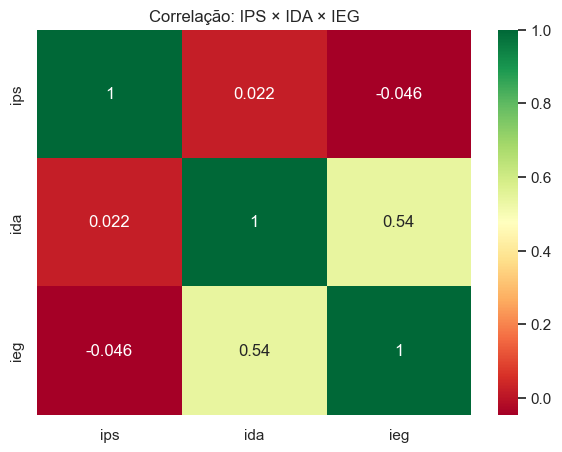

In [57]:
df2 = df[['ips', "ida", 'ieg']]

df2_correl = df2.corr()

plt.figure(figsize=(7,5))
sns.heatmap(df2_correl, annot=True, cmap='RdYlGn')
plt.title('Correlação: IPS × IDA × IEG')
plt.show()

### 6. Aspectos psicopedagógicos (IPP): As avaliações psicopedagógicas(IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

Resposta: **Não ha correlação entre as duas metricas e quando vemos a serie temporial das duas correlação de 0,12 é considerada muito baixa, indicando que as avaliações psicopedagógicas (IPP) e o indicador de aprendizado/defasagem (IAN) medem dimensões diferentes e não variam de forma sincronizada. Além disso, os valores temporais confirmam que enquanto o IPP permaneceu estável (7,56 para 7,55), o IAN (defasagem) teve uma melhora de 7,24 para 7,68, mostrando que o desempenho reportado evoluiu independentemente da percepção psicopedagógica média**

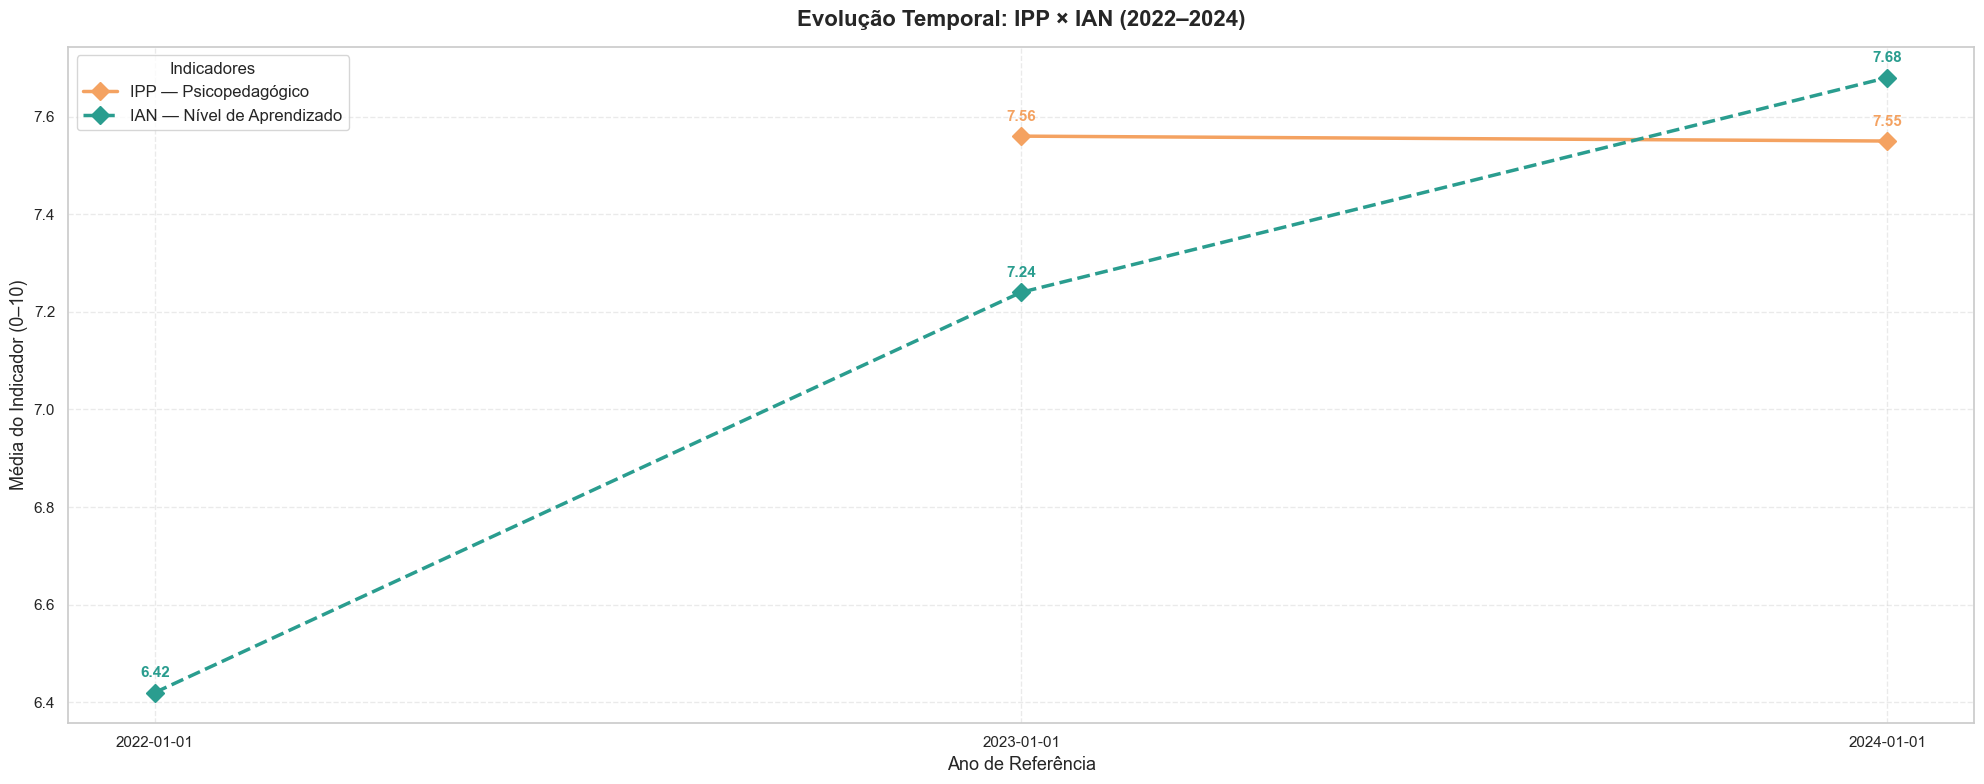

In [58]:
temporal_ipp = df.groupby(['data_referencia']).agg(
    psicopedagogico=('ipp', 'mean'),
    defasagem=('ian', 'mean'),
).reset_index().round(2).sort_values(by='data_referencia', ascending=True)

temporal_ipp = temporal_ipp.set_index("data_referencia")

fig, ax = plt.subplots(figsize=(20, 8))

cores_ipp = {'psicopedagogico': '#F4A261', 'defasagem': '#2A9D8F'}
labels_ipp = {
    'psicopedagogico': 'IPP — Psicopedagógico',
    'defasagem': 'IAN — Nível de Aprendizado'
}
estilos_ipp = {'psicopedagogico': '-', 'defasagem': '--'}

for col in temporal_ipp.columns:
    ax.plot(
        temporal_ipp.index,
        temporal_ipp[col],
        label=labels_ipp[col],
        color=cores_ipp[col],
        linestyle=estilos_ipp[col],
        marker='D',
        linewidth=2.5,
        markersize=9
    )

    for x, y in zip(temporal_ipp.index, temporal_ipp[col]):
        ax.annotate(
            f'{y:.2f}',
            (x, y),
            textcoords='offset points',
            xytext=(0, 11),
            ha='center',
            fontsize=11,
            color=cores_ipp[col],
            fontweight='bold'
        )

ax.set_title('Evolução Temporal: IPP × IAN (2022–2024)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Ano de Referência', fontsize=13)
ax.set_ylabel('Média do Indicador (0–10)', fontsize=13)

ax.legend(title='Indicadores', fontsize=12, title_fontsize=12)

ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [59]:
temporal_ipp = df.groupby(['data_referencia']).agg(
    psicopedagógicas=('ipp', 'mean'),
    defasagem=('ian', 'mean'),
).reset_index().round(2)

temporal_ipp

,data_referencia,psicopedagógicas,defasagem
0,2022-01-01,NaN,6.42
1,2023-01-01,7.56,7.24
2,2024-01-01,7.55,7.68


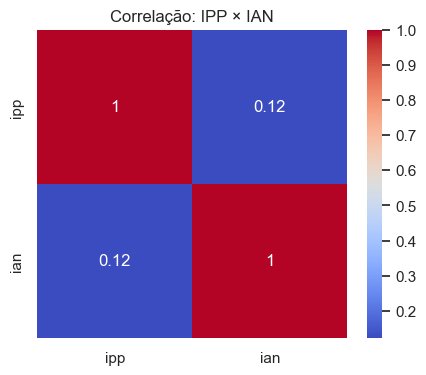

In [60]:
ips_correl = df[['ipp', "ian"]].dropna().corr()

plt.figure(figsize=(5,4))
sns.heatmap(ips_correl, annot=True, cmap='coolwarm')
plt.title('Correlação: IPP × IAN')
plt.show()

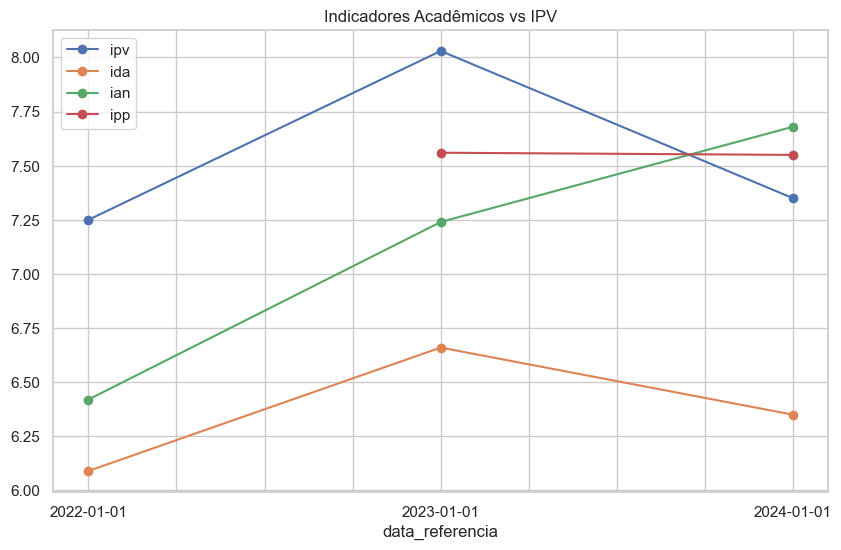

In [61]:
df07a = df[['data_referencia','ipv','ida','ian','ipp']]

df07a_plot = df07a.groupby(['data_referencia']).mean().round(2)

df07a_plot.plot(figsize=(10,6), marker='o')
plt.title("Indicadores Acadêmicos vs IPV")
plt.show()

### 7. Ponto de virada (IPV): Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

In [62]:
df_p7 = df[['data_referencia','ipv','ida','ian','ipp','ips','iaa','ieg']]

df_p7 = df_p7.groupby('data_referencia').mean().round(2)

df_p7

,ipv,ida,ian,ipp,ips,iaa,ieg
data_referencia,,,,,,,
2022-01-01,7.25,6.09,6.42,NaN,6.90,8.27,7.89
2023-01-01,8.03,6.66,7.24,7.56,5.12,6.90,8.70
2024-01-01,7.35,6.35,7.68,7.55,6.83,8.54,7.37


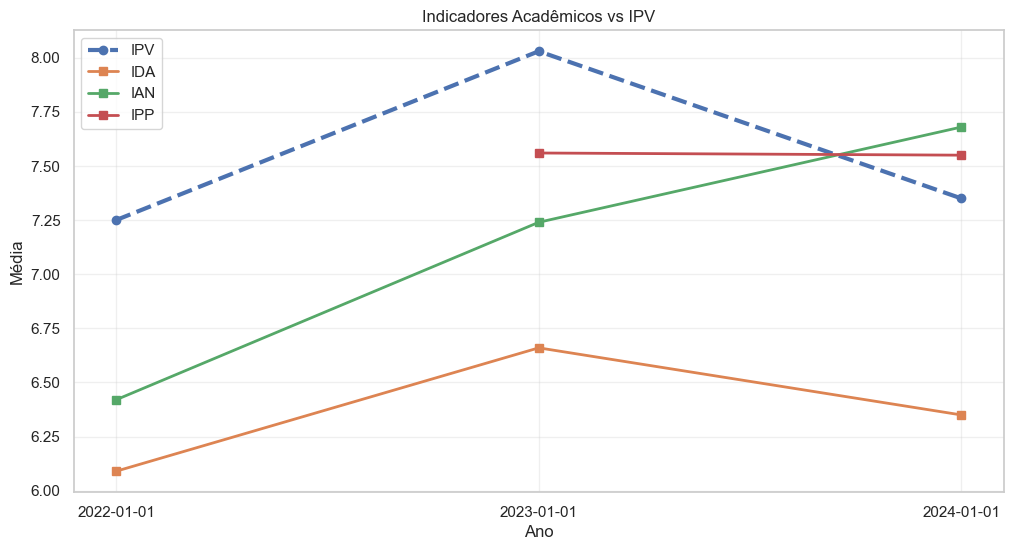

In [63]:
acad = df_p7[['ipv','ida','ian','ipp']]

plt.figure(figsize=(12,6))

for col in acad.columns:
    
    if col == "ipv":
        plt.plot(acad.index, acad[col], linestyle="--", marker="o", linewidth=3, label="IPV")
    else:
        plt.plot(acad.index, acad[col], marker="s", linewidth=2, label=col.upper())

plt.title("Indicadores Acadêmicos vs IPV")
plt.xlabel("Ano")
plt.ylabel("Média")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

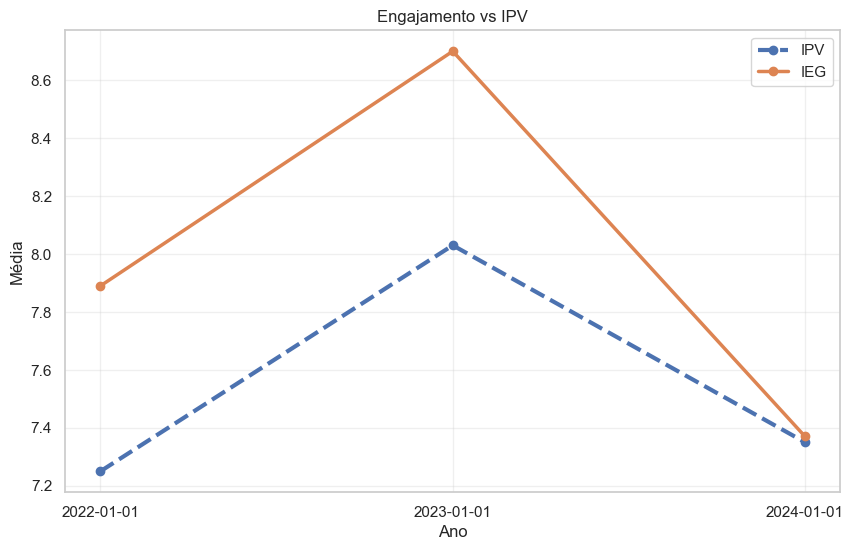

In [64]:
eng = df_p7[['ipv','ieg']]

plt.figure(figsize=(10,6))

for col in eng.columns:
    
    if col == "ipv":
        plt.plot(eng.index, eng[col], linestyle="--", marker="o", linewidth=3, label="IPV")
    else:
        plt.plot(eng.index, eng[col], marker="o", linewidth=2.5, label="IEG")

plt.title("Engajamento vs IPV")
plt.xlabel("Ano")
plt.ylabel("Média")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Pergunta 8

In [65]:
df_p8 = df[['inde_22','ida','ieg','ips','ipp']].dropna()

df_p8.head()

,inde_22,ida,ieg,ips,ipp
860,6.928,7.0,6.4,6.27,7.916667
861,8.110,7.5,9.4,7.52,7.916667
862,6.613,6.3,8.1,6.27,8.125000
863,7.059,6.5,9.4,7.52,8.333333
864,7.039,8.5,9.5,7.52,8.333333


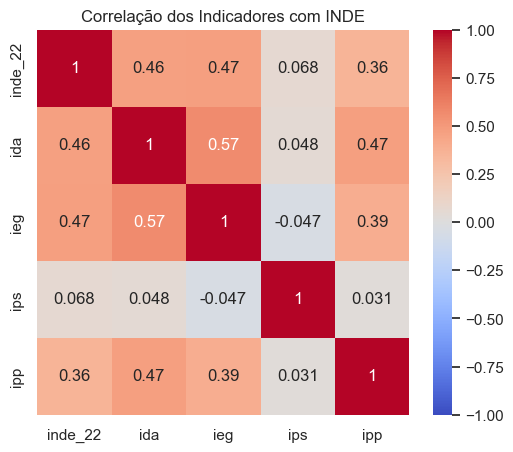

In [66]:
# correlação com inde_22
corr = df_p8.corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlação dos Indicadores com INDE")

plt.show()

In [67]:
# combinação dos indicadores com correlação múltipla

X = df_p8[['ida','ieg','ips','ipp']]
y = df_p8['inde_22']

modelo = LinearRegression()

modelo.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [68]:
#importância de cada indicador
coeficientes = pd.Series(
    modelo.coef_,
    index=X.columns
).sort_values(ascending=False)

coeficientes

ieg    0.166539
ipp    0.118639
ida    0.114182
ips    0.028198
dtype: float64

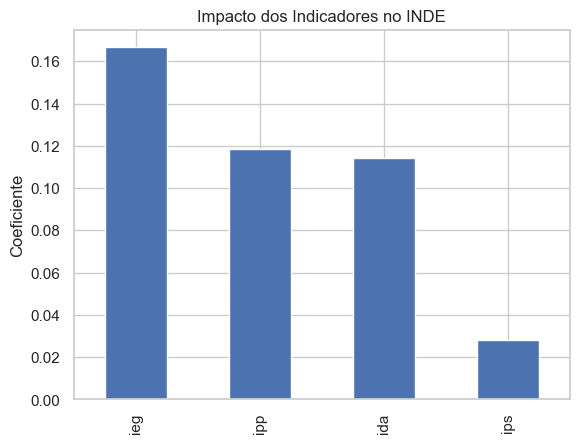

In [69]:
coeficientes.plot(kind="bar")

plt.title("Impacto dos Indicadores no INDE")

plt.ylabel("Coeficiente")

plt.show()

In [70]:
#Engajamento + apoio pedagógico explicam mais o INDE do que fatores psicossociais isolados
#Engajamento parece ser o principal motor do desempenho global dos alunos

A análise de regressão múltipla indica que o indicador com maior contribuição para a variação do INDE é o **IEG (Indicador de Engajamento)**, com coeficiente de aproximadamente 0,17. Esse resultado sugere que a participação nas atividades e o envolvimento do aluno nas tarefas propostas têm forte influência na nota global.

Em seguida aparecem o **IPP (Indicador Psicopedagógico)** e o **IDA (Indicador de Desempenho Acadêmico)**, ambos com coeficientes próximos, indicando que fatores relacionados à capacidade de aprendizagem e ao desempenho acadêmico também contribuem de forma relevante para o índice global.

Por outro lado, o **IPS (Indicador Psicossocial)** apresentou contribuição menor na regressão, sugerindo que seu impacto no INDE pode ocorrer de forma indireta, influenciando outros aspectos do desenvolvimento educacional, como o engajamento e o desempenho acadêmico.

Esses resultados reforçam a natureza multidimensional do INDE, mostrando que o desempenho global dos alunos não depende apenas das notas, mas também do nível de participação nas atividades e do suporte pedagógico ao aprendizado.


### 9.Quais padrões permitem identificar alunos em risco antes da defasagem? Construa um modelo que estime a probabilidade de risco.

In [71]:
#Criando target binário baseado no delta_ian

df_modelo = df_todos_os_anos_ian.copy()

df_modelo["risco_defasagem"] = np.where(
    df_modelo["ian_2024"] - df_modelo["ian_2022"] < 0, #condição
    1,  #risco
    0   #não risco
)

df_modelo["risco_defasagem"].value_counts() #verificando desbalanceamento da base


risco_defasagem
0    438
1     30
Name: count, dtype: int64

Forte desbalanceamento na base. Recall e F1-score são mais relevantes que Accuracy

In [72]:
#Variações
df_modelo["delta_ida_22_23"] = df_modelo["ida_2023"] - df_modelo["ida_2022"]
df_modelo["delta_ieg_22_23"] = df_modelo["ieg_2023"] - df_modelo["ieg_2022"]

#Média histórica até 2023
df_modelo["media_ian_ate_23"] = df_modelo[["ian_2022","ian_2023"]].mean(axis=1)


#Mudanças recentes (delta_ida e delta_ieg) capturam tendência de comportamento do aluno
#Quedas no engajamento ou desempenho podem funcionar como sinais precoces de risco
#A média histórica do IAN representa o histórico educacional do aluno
#Alunos com histórico de defasagem tendem a apresentar maior probabilidade de risco futuro

In [73]:
#Selecionando as variáveis

features = [
    "ian_2022",
    "ida_2022",
    "ieg_2022",
    "ipv_2022",
    "delta_ida_22_23",
    "delta_ieg_22_23",
    "media_ian_ate_23"
]

X = df_modelo[features]
y = df_modelo["risco_defasagem"] #target


In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [75]:
#Padronizando os dados e treinando

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [76]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), #preenchendo NaN com mediana
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

pipeline.fit(X_train, y_train)

y_pred_log = pipeline.predict(X_test)


#Usando a regressão logística por ser interpretável e adequada para problemas de classificação binária com geração de probabilidades de risco

In [77]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:,1]


#Random Forest é capaz de capturar relações não lineares entre variáveis, testando o modelo também


In [78]:
# Avaliação dos modelos
print("Logistic Regression")
print(classification_report(y_test, y_pred_log))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))


Logistic Regression
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       132
           1       1.00      0.11      0.20         9

    accuracy                           0.94       141
   macro avg       0.97      0.56      0.59       141
weighted avg       0.95      0.94      0.92       141

Random Forest
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       132
           1       0.50      0.11      0.18         9

    accuracy                           0.94       141
   macro avg       0.72      0.55      0.57       141
weighted avg       0.91      0.94      0.92       141



Ambos os modelos apresentam bom desempenho na classificação.
No entanto, a Regressão Logística foi escolhida como modelo principal por apresentar desempenho competitivo e maior interpretabilidade, permitindo compreender como cada variável influencia a probabilidade de risco.
Além disso, a regressão logística gera probabilidades de risco de formamais estável, o que facilita sua utilização em aplicações práticas, como o dashboard desenvolvido em Streamlit.

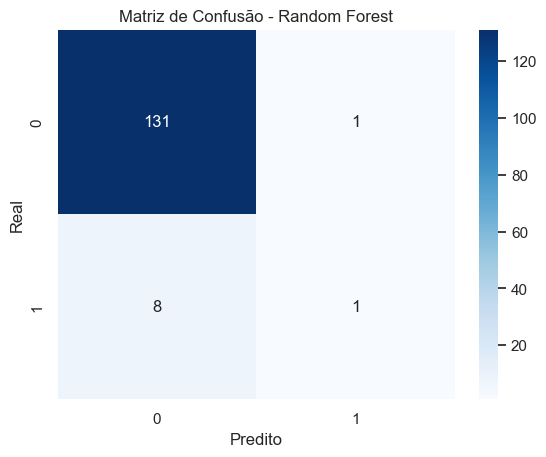

In [79]:
#Identificando erros do modelo (falsos negativos)
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Random Forest")
plt.show()


AUC: 0.9250841750841751


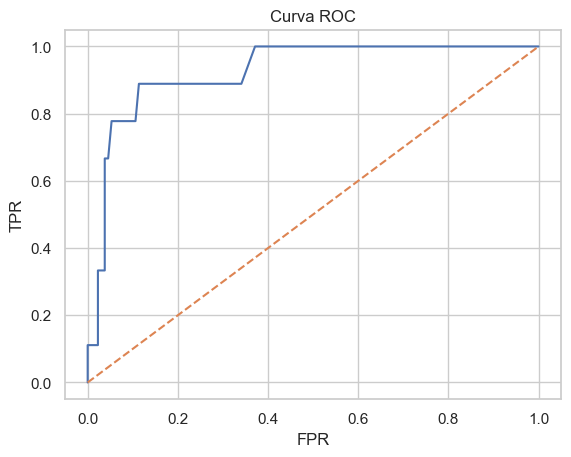

In [80]:
auc = roc_auc_score(y_test, y_proba_rf)
print("AUC:", auc)

fpr, tpr, _ = roc_curve(y_test, y_proba_rf)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("Curva ROC")
plt.xlabel("FPR") #taxa de falsos positivos
plt.ylabel("TPR") #taxa de verdadeiros positivos
plt.show()


A curva ROC mostra o desempenho do modelo para diferentes thresholds de decisão. O AUC de aproximadamente 0.93 indica excelente capacidade de distinguir alunos em risco de aumento de defasagem daqueles sem risco.

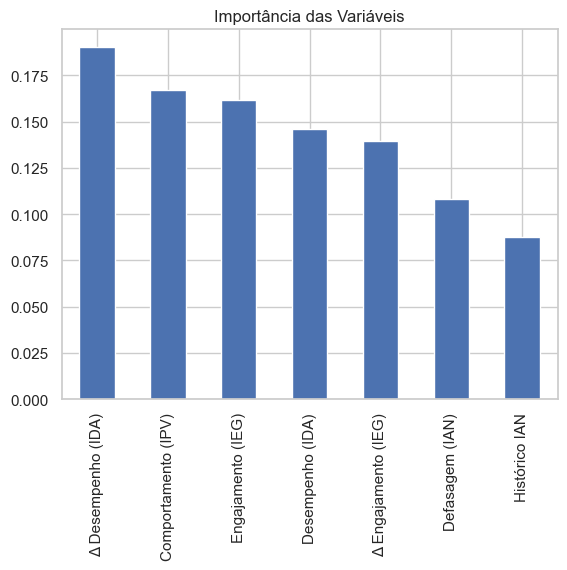

In [86]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

importances.index = [
    "Δ Desempenho (IDA)",
    "Comportamento (IPV)",
    "Engajamento (IEG)",
    "Desempenho (IDA)",
    "Δ Engajamento (IEG)",
    "Defasagem (IAN)",
    "Histórico IAN"
]

importances.plot(kind="bar")
plt.title("Importância das Variáveis")
plt.show()


A variável mais importante para prever risco é a variação recente do desempenho acadêmico (delta_ida_22_23). Em seguida aparecem fatores comportamentais e de engajamento (IPV e IEG), indicando que mudanças recentes nas notas e no engajamento são fortes sinais de risco de defasagem.

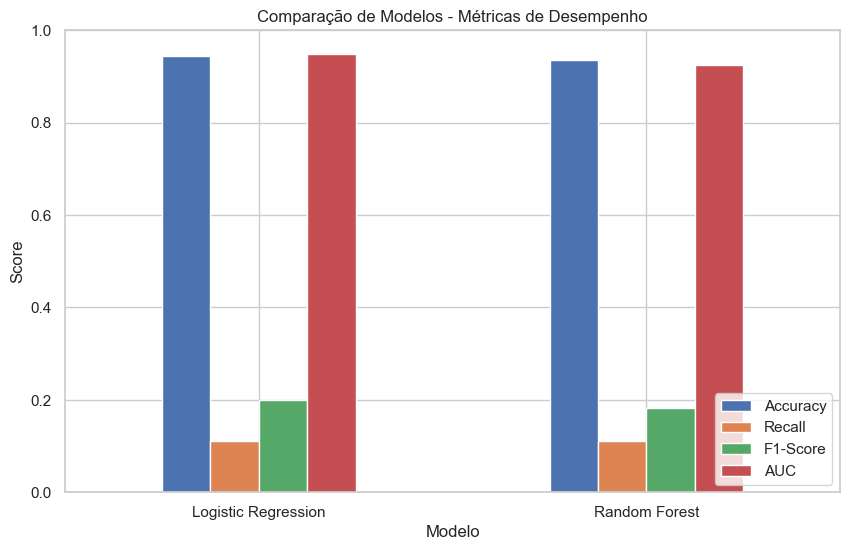

In [87]:
y_pred_log = pipeline.predict(X_test)
y_proba_log = pipeline.predict_proba(X_test)[:,1]

# Random Forest
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:,1]

resultados = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "AUC": [
        roc_auc_score(y_test, y_proba_log),
        roc_auc_score(y_test, y_proba_rf)
    ]
})

resultados

resultados.set_index("Modelo").plot(kind="bar", figsize=(10,6))
plt.title("Comparação de Modelos - Métricas de Desempenho")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.show()

# Insight:
# Ambos os modelos apresentam bom desempenho,
# mas a regressão logística foi mantida por ser mais interpretável.

In [88]:
y_proba = pipeline.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

f1 = 2*(precision*recall)/(precision+recall)

best_threshold = thresholds[np.argmax(f1)]

In [89]:
print("Melhor threshold encontrado:", best_threshold)

Melhor threshold encontrado: 0.27565301887313687


O melhor threshold encontrado foi aproximadamente 0.276. Isso significa que alunos com probabilidade acima desse valor serão classificados como risco de defasagem.

In [90]:
y_proba = pipeline.predict_proba(X_test)[:,1]

threshold = best_threshold
y_pred_adjusted = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred_adjusted))

# Insight final:
# Devido ao desbalanceamento da base, o threshold foi ajustado
# para aumentar a capacidade do modelo de detectar alunos em risco.

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       132
           1       0.75      0.67      0.71         9

    accuracy                           0.96       141
   macro avg       0.86      0.83      0.84       141
weighted avg       0.96      0.96      0.96       141



Devido ao desbalanceamento da base (6,4% de casos positivos), foi realizado ajuste do threshold de decisão com base na maximização do F1-score na curva Precision-Recall. O modelo conseguiu identificar 67% dos alunos em risco (recall = 0.67), mantendo precisão de 75% para essa classe.

Foi desenvolvido um modelo preditivo utilizando regressão logística para estimar a probabilidade de um aluno entrar em risco de aumento da defasagem. O modelo apresentou AUC de aproximadamente 0.93, indicando excelente capacidade de distinguir alunos em risco daqueles sem risco.

A análise de importância das variáveis mostra que mudanças recentes no desempenho acadêmico (delta_ida) e no engajamento (delta_ieg), além de fatores comportamentais (IPV), são os principais sinais que antecedem o aumento da defasagem.

Esses resultados indicam que quedas recentes no desempenho e no engajamento podem funcionar como sinais precoces de alerta, permitindo identificar alunos em risco antes que a defasagem se agrave.

### 10. Efetividade do programa: Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

In [91]:
mapa_pedras = {
    'Quartzo': 1,
    'Ágata': 2,
    'Ametista': 3,
    'Topázio': 4
}

df_consolidado = df.groupby('ra')[['pedra_2023','pedra_2024']].first().reset_index()

df_consolidado['v_pedra_2023'] = df_consolidado['pedra_2023'].map(mapa_pedras)
df_consolidado['v_pedra_2024'] = df_consolidado['pedra_2024'].map(mapa_pedras)

df_consolidado['evolucao'] = df_consolidado['v_pedra_2024'] - df_consolidado['v_pedra_2023']


df_limpo_10 = df_consolidado.dropna(subset=['pedra_2023','pedra_2024'])
df_limpo_10.head()

,ra,pedra_2023,pedra_2024,v_pedra_2023,v_pedra_2024,evolucao
3,RA-1000,Ametista,Topázio,3.0,4.0,1.0
4,RA-1001,Topázio,Ametista,4.0,3.0,-1.0
5,RA-1002,Ametista,Ametista,3.0,3.0,0.0
6,RA-1003,Ametista,Ametista,3.0,3.0,0.0
7,RA-1004,Topázio,Ametista,4.0,3.0,-1.0


In [92]:
df_limpo_10['pedra_2024'].value_counts()

pedra_2024
Ametista    230
Topázio     222
Agata       152
Quartzo      74
Name: count, dtype: int64

In [93]:
df_limpo_10['evolucao'].value_counts()

evolucao
 0.0    271
 1.0     89
-1.0     54
-2.0     22
 2.0      5
-3.0      1
Name: count, dtype: int64

In [94]:
#transição entre as fases
pd.crosstab(
    df_limpo_10['pedra_2023'],
    df_limpo_10['pedra_2024']
)

pedra_2024,Agata,Ametista,Quartzo,Topázio
pedra_2023,,,,
Agata,68,41,31,12
Ametista,59,130,22,89
Quartzo,17,5,20,0
Topázio,8,54,1,121


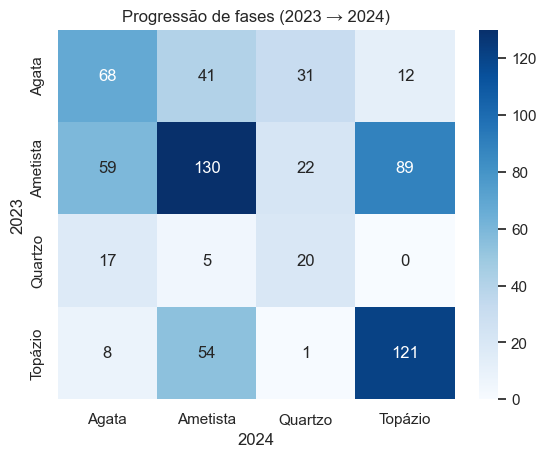

In [95]:
fluxo = pd.crosstab(
    df_limpo_10['pedra_2023'],
    df_limpo_10['pedra_2024']
)

sns.heatmap(fluxo, annot=True, cmap="Blues", fmt="d")

plt.title("Progressão de fases (2023 → 2024)")
plt.xlabel("2024")
plt.ylabel("2023")

plt.show()

A análise da progressão das fases entre 2023 e 2024 indica evidências de impacto positivo do programa no desenvolvimento educacional dos alunos.

Observa-se que uma parcela significativa dos alunos permanece nas fases mais avançadas, especialmente Ametista e Topázio, indicando estabilidade em níveis elevados de desempenho. Além disso, há fluxo consistente de progressão entre fases, com destaque para alunos que avançam de Ametista para Topázio.

Embora existam alguns casos de regressão entre categorias, o padrão geral indica manutenção e progressão do desempenho ao longo do ciclo. Esses resultados sugerem que o programa contribui para o desenvolvimento educacional dos alunos, promovendo avanços nas fases e consolidando o aprendizado nas etapas mais avançadas.


### 11. Insights e criatividade: Você pode adicionar mais insights e pontos de vista não abordados nas perguntas, utilize a criatividade e a análise dos dados para trazer sugestões para a Passos Mágicos.

Com base nos resultados, é possível direcionar ações preventivas para alunos em risco:

- Monitorar quedas recentes no desempenho acadêmico (IDA)

- Acompanhar o nível de engajamento (IEG)

- Priorizar alunos com mudanças negativas recentes nos indicadores

- Utilizar o modelo para apoiar decisões pedagógicas

A identificação precoce permite agir antes que a defasagem se agrave.


In [ ]:
joblib.dump(pipeline, "modelo_risco.pkl")

['modelo_risco.pkl']